In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# First look
print("Shape:", df.shape)
print("\n--- First 5 rows ---")
print(df.head())

# Column types
print("\n--- Data Types ---")
print(df.dtypes)

# Missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Target distribution
print("\n--- Churn Distribution ---")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Shape: (7043, 21)

--- First 5 rows ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport Streamin

In [3]:
import os
os.makedirs('../reports', exist_ok=True)
print("✅ reports/ folder ready")

✅ reports/ folder ready


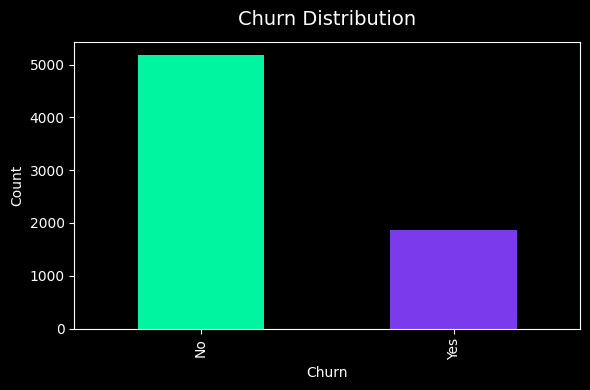

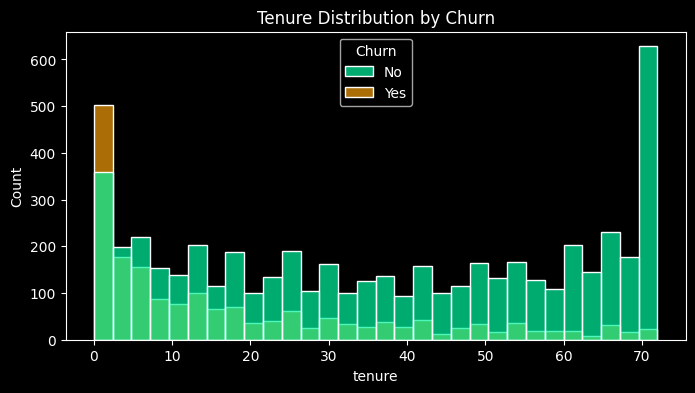

C:\Users\walid\AppData\Local\Temp\ipykernel_14688\369265994.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges',


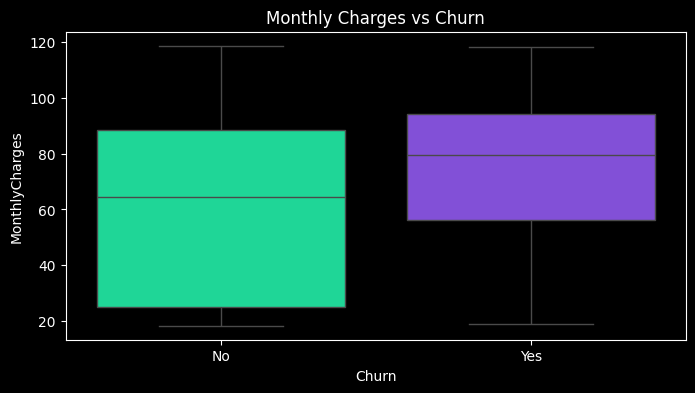

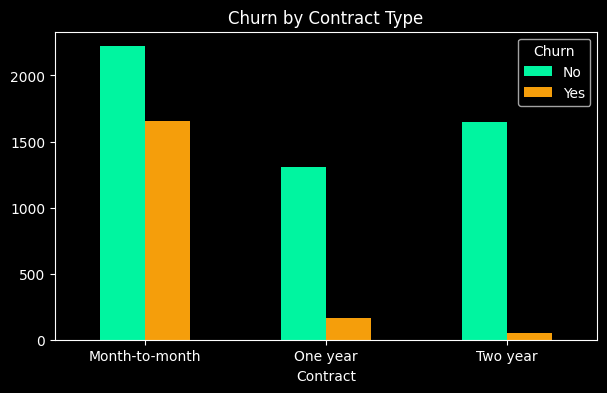

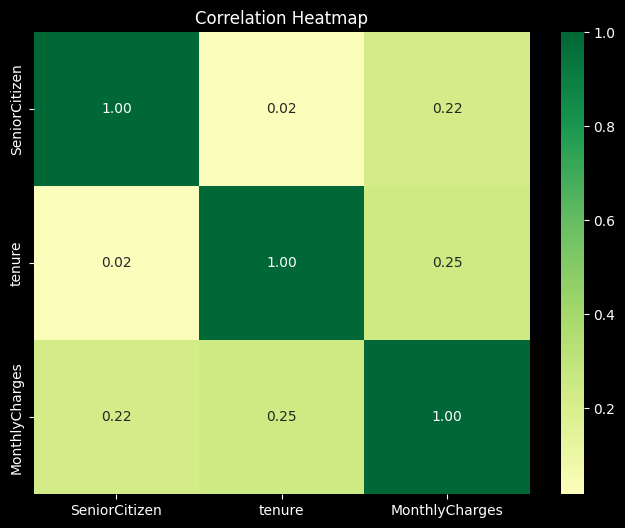

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

# ---- 1. CHURN DISTRIBUTION ----
fig, ax = plt.subplots(figsize=(6, 4))
df['Churn'].value_counts().plot(kind='bar', color=['#00f5a0', '#7c3aed'],
                                   edgecolor='none', ax=ax)
ax.set_title('Churn Distribution', fontsize=14, pad=12)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/churn_dist.png', dpi=150)
plt.show()

# ---- 2. TENURE vs CHURN ----
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='tenure', hue='Churn', bins=30,
             palette=['#00f5a0', '#f59e0b'], alpha=0.7)
plt.title('Tenure Distribution by Churn')
plt.savefig('../reports/tenure_churn.png', dpi=150)
plt.show()

# ---- 3. MONTHLY CHARGES vs CHURN ----
plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges',
            palette=['#00f5a0', '#7c3aed'])
plt.title('Monthly Charges vs Churn')
plt.savefig('../reports/monthly_churn.png', dpi=150)
plt.show()

# ---- 4. CONTRACT TYPE ----
ct = df.groupby(['Contract', 'Churn']).size().unstack()
ct.plot(kind='bar', color=['#00f5a0', '#f59e0b'], figsize=(7, 4))
plt.title('Churn by Contract Type')
plt.xticks(rotation=0)
plt.savefig('../reports/contract_churn.png', dpi=150)
plt.show()

# ---- 5. CORRELATION HEATMAP ----
num_cols = df.select_dtypes(include='number').columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.savefig('../reports/corr_heatmap.png', dpi=150)
plt.show()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

def preprocess(df):
    df = df.copy()

    # --- Drop customerID (not useful) ---
    df = df.drop('customerID', axis=1)

    # --- Fix TotalCharges (has spaces, should be numeric) ---
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

    # --- Encode target variable ---
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)

    # --- Binary columns: Yes/No → 1/0 ---
    binary_cols = ['Partner', 'Dependents', 'PhoneService',
                   'PaperlessBilling', 'SeniorCitizen']
    for col in binary_cols:
        if df[col].dtype == object:
            df[col] = (df[col] == 'Yes').astype(int)

    # --- One-Hot Encode multi-category columns ---
    cat_cols = ['gender', 'MultipleLines', 'InternetService',
                'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies',
                'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    # --- Split features & target ---
    X = df.drop('Churn', axis=1)
    y = df['Churn']

    # --- Train / Test split (80/20, stratified) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # --- Scale numerical features ---
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test, scaler, X.columns.tolist()

In [8]:
import sys
!{sys.executable} -m pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\walid\AppData\Local\Temp\ipykernel_14688\1623829287.py:23: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


✅ Data loaded and preprocessed!
   Train size: (5634, 30), Test size: (1409, 30)

=== Logistic Regression ===
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409


=== Random Forest ===
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86      1035
       Churn       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409


=== XGBoost ===
              precision    recall  f1-score   support

    No Churn       0.84      0.88      0.86      1035
       Churn       0.61      0.54      0.57       374

    accuracy                    

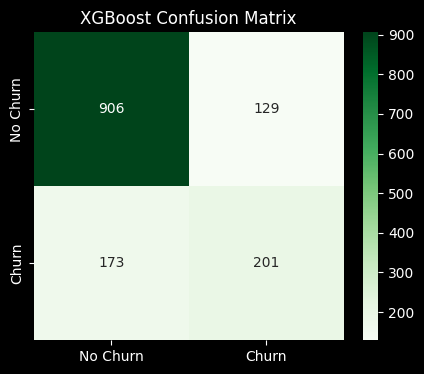

In [12]:
import sys, os
sys.path.append(os.path.abspath('..'))

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              f1_score, roc_auc_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# ============================================================
# PREPROCESSING FUNCTION (inline, no import needed)
# ============================================================
def preprocess(df):
    df = df.copy()
    df = df.drop('customerID', axis=1)
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
    df['Churn'] = (df['Churn'] == 'Yes').astype(int)

    binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
    for col in binary_cols:
        if df[col].dtype == object:
            df[col] = (df[col] == 'Yes').astype(int)

    cat_cols = ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
                'StreamingMovies', 'Contract', 'PaymentMethod']
    df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

    X = df.drop('Churn', axis=1)
    y = df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    scaler = StandardScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols]  = scaler.transform(X_test[num_cols])

    return X_train, X_test, y_train, y_test, scaler, X.columns.tolist()

# ============================================================
# LOAD & PREPROCESS
# ============================================================
df = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
X_train, X_test, y_train, y_test, scaler, feature_names = preprocess(df)
print("✅ Data loaded and preprocessed!")
print(f"   Train size: {X_train.shape}, Test size: {X_test.shape}")

# ============================================================
# DEFINE & TRAIN MODELS
# ============================================================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':             XGBClassifier(eval_metric='logloss', random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
    results[name] = {
        'F1 Score':    round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':    round(roc_auc_score(y_test, y_prob), 4),
        'CV F1 Mean': round(cv_scores.mean(), 4),
    }
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# ============================================================
# COMPARE RESULTS
# ============================================================
results_df = pd.DataFrame(results).T
print("\n--- Model Comparison ---")
print(results_df.sort_values('F1 Score', ascending=False))

# ============================================================
# CONFUSION MATRIX
# ============================================================
os.makedirs('../reports', exist_ok=True)
best_model = models['XGBoost']
cm = confusion_matrix(y_test, best_model.predict(X_test))

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('XGBoost Confusion Matrix')
plt.savefig('../reports/confusion_matrix.png', dpi=150)
plt.show()

In [ ]:
import sys
!{sys.executable} -m pip install imbalanced-learn joblib xgboost scikit-learn streamlit

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}
Fitting 5 folds for each of 54 candidates, totalling 270 fits


c:\Users\walid\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:14:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best CV F1:  0.8364
              precision    recall  f1-score   support

           0       0.87      0.78      0.82      1035
           1       0.53      0.67      0.59       374

    accuracy                           0.75      1409
   macro avg       0.70      0.73      0.71      1409
weighted avg       0.78      0.75      0.76      1409



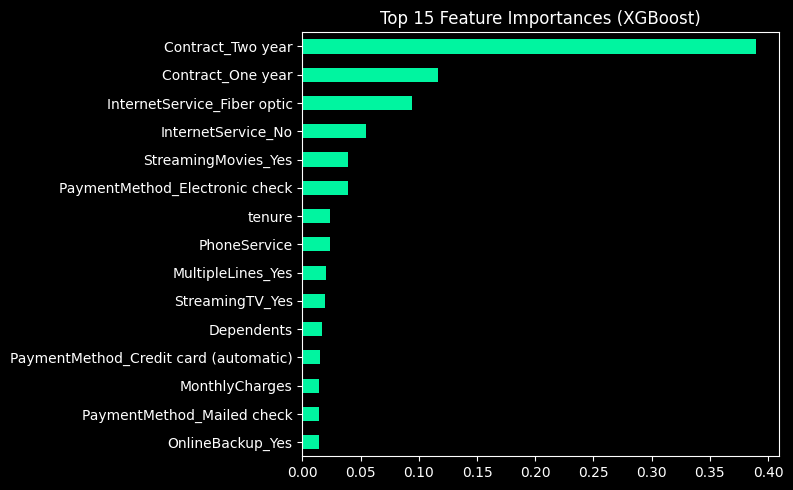

✅ Model saved!


In [18]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
import joblib
import matplotlib.pyplot as plt

# ---- 1. APPLY SMOTE ----
# Synthetic Minority Oversampling Technique
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", y_train_sm.value_counts().to_dict())

# ---- 2. HYPERPARAMETER TUNING ----
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

xgb = XGBClassifier(use_label_encoder=False,
                    eval_metric='logloss', random_state=42)

grid_search = GridSearchCV(
    xgb, param_grid, cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train_sm, y_train_sm)

print("Best Params:", grid_search.best_params_)
print("Best CV F1: ", round(grid_search.best_score_, 4))

# ---- 3. EVALUATE BEST MODEL ----
best_xgb = grid_search.best_estimator_
y_pred = best_xgb.predict(X_test)
print(classification_report(y_test, y_pred))

# ---- 4. FEATURE IMPORTANCE ----
importances = pd.Series(best_xgb.feature_importances_,
                         index=feature_names).sort_values(ascending=False)[:15]

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='#00f5a0')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=150)
plt.show()

# ---- 5. SAVE THE MODEL ----
joblib.dump(best_xgb, '../models/xgb_churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Model saved!")